# RICE LEAF DISEASE DETECTION USING CNN


**CAPSTONE PROJECT SUBMITTED IN PARTIAL FULLFILLMENT OF THE REQUIREMENT FOR CERTIFICATION AS CERTIFIED DATA SCIENTISTS AT DATAMITES GLOBAL TRAINING INSTITUTE**

**PROJECT ID:**  &emsp;  PRCP-1001-RiceLeaf Disease Detection

**TEAM ID:**  &emsp;    &emsp;  PTID-CDS-SEP-25-3143

**TEAM MEMBERS:**
| Sn | Name | Email |
|---|---|---|
| 1.   | Vinil Sukumar | vinilsukumar2698@gmail.com |
| 2.   | Sindhya Sivaram | cynthiasunil8@gmail.com |
| 3.   | Keerthi Cheerath | keerthicheerath@gmail.com |
| 4.   | Musa Leteipa Sere | musa.sere7@gmail.com |

## 1. PROBLEM STATEMENT

Rice is a staple food to many across the world. It contributes significant to sustainable agriculture and food security. The production of this critical food crop faces immense challenges owing to prevalence of various diseases that affect its yield. Bacterial leaf blight(BLB), brown spot(BS) and leaf smut(LS) are three most common rice diseases which can cause significant damage to the crop yield. Timely and precisely diagnosis of these diseases is essential to be to mitigate the negative effects. This project seeks to advance develop a model to detect these disease early for effective management. The scope of the project covers the following tasks:
->Task 1:- Prepare a complete data analysis report on the given data.
->Task 2:- Create a model which can classify the three major attacking diseases of rice plants like leaf blast, bacterial blight and brown spot.
->Task 3:- Analyze various techniques like Data Augmentation, etc and create a report on that.

## 2. Domain Analysis

This project focuses on detection of rice leaf diseases. The diseases under study are discussed below: * Bacterial leaf blight: Bacterial leaf blight is caused by a bacterium Xanthomonas oryzae pv. oryzae. This disease can cause immense damage on to farms resulting low yield and famine especially where rice is a staple food * Brown spot: It is a rice leaf disease caused by a fungus Bipolaris oryzae. Brow spot creates brown spots on the leaves and can cause significant to crop yield. * Leaf smut: It is caused by a fungus Entyloma oryzae and spread rapidly. It's effects on the yield of the crop are not severe.

## 3. Task 1:- Installing and Importing Libraries

In [1]:
#!pip install "ml-dtypes<0.4.1" --force-reinstall
#!pip install "protobuf<6" --force-reinstall
#!pip install opencv-python
#!pip install opencv-contrib-python
#!pip install pillow
#!pip uninstall -y tensorflow tensorflow-intel keras ml-dtypes numpy
#!pip install "numpy<2" "ml-dtypes<0.4.1" "tensorflow==2.16.1"
#!pip install ImageHash


In [1]:
# Libraries for data framing, data manipulation and computing
import numpy as np     
import pandas as pd
from PIL import Image
#import cv2
import imagehash
import glob

# Libraries for data visualization
import matplotlib.pyplot as plt
import matplotlib.image as img
import seaborn as sns

# Libraries for manipulation and management of files and directories
import os

# Libraries for training and evaluation of the models
import tensorflow as tf

# Library for suppressing warnings
import warnings
warnings.filterwarnings("ignore")


In [2]:
# Path to rice diseases image dataset directory
dataset_path = r"C:\Studies\Intern\project-3\Dataset"

In [3]:
# creating a main directory and checking subfolders under it
main_dir  = os.listdir(dataset_path)
main_dir

['Bacterial leaf blight', 'Brown spot', 'Leaf smut']

In [4]:
# Creating dataframe for the images and labels

#  Define dataset path
#dataset_path = r"C:\Users\sindh\OneDrive\Rice_Leaf_Data"

#  List all items in the dataset folder
main_dir = os.listdir(dataset_path)

#  Initialize lists
img_list = []
label_list = []

#   Loop through each folder (class label)
for label in main_dir:
    label_path = os.path.join(dataset_path, label)

    # Skip if it's not a folder (e.g., a .zip file)
    if not os.path.isdir(label_path):
        continue

    #  Loop through all image files inside the class folder
    for img_file in os.listdir(label_path):
        fpat = os.path.join(label_path, img_file)
        img_list.append(fpat)
        label_list.append(label)

#  Create DataFrame
df = pd.DataFrame({'Image': img_list, 'Label': label_list})

#  Display few rows
print(df.head())
print("Total images:", len(df))


                                               Image                  Label
0  C:\Studies\Intern\project-3\Dataset\Bacterial ...  Bacterial leaf blight
1  C:\Studies\Intern\project-3\Dataset\Bacterial ...  Bacterial leaf blight
2  C:\Studies\Intern\project-3\Dataset\Bacterial ...  Bacterial leaf blight
3  C:\Studies\Intern\project-3\Dataset\Bacterial ...  Bacterial leaf blight
4  C:\Studies\Intern\project-3\Dataset\Bacterial ...  Bacterial leaf blight
Total images: 119


In [5]:
# Checking shape of the dataframe
df.shape

(119, 2)

In [6]:
# Checking the number of images in sub-directory representing a disease
print("======= Images Count Summary =======")
df['Label'].value_counts()

======= Images Count Summary =======


Label
Bacterial leaf blight    40
Brown spot               40
Leaf smut                39
Name: count, dtype: int64

In [7]:
# Checking dimensions of Image dataset:
image_dimensions = {}
for sd in main_dir:
    for filename in os.listdir(f"{dataset_path}\\{sd}"):
    #for filename in os.listdir(folder_path):
        if filename.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp', '.tiff')):
            image_path = os.path.join(f"{dataset_path}\\{sd}", filename)
            try:
                with Image.open(image_path) as img:
                    width, height = img.size
                    image_dimensions[filename] = {"width": width, "height": height}
            except Exception as e:
                print(f"Error processing {filename}: {e}")

for image_name, dimensions in image_dimensions.items():
    print(f"Image: {image_name}, Dimensions: {dimensions['width']}x{dimensions['height']}")

Image: DSC_0365.JPG, Dimensions: 3081x897
Image: DSC_0366.jpg, Dimensions: 3081x897
Image: DSC_0367.JPG, Dimensions: 3081x897
Image: DSC_0370.jpg, Dimensions: 3081x897
Image: DSC_0372.JPG, Dimensions: 3081x897
Image: DSC_0373.JPG, Dimensions: 3081x897
Image: DSC_0374.JPG, Dimensions: 3081x897
Image: DSC_0375.JPG, Dimensions: 3081x897
Image: DSC_0376.JPG, Dimensions: 3081x897
Image: DSC_0377.JPG, Dimensions: 3081x897
Image: DSC_0378.JPG, Dimensions: 3081x897
Image: DSC_0379.JPG, Dimensions: 3081x897
Image: DSC_0380.JPG, Dimensions: 3081x897
Image: DSC_0381.JPG, Dimensions: 3081x897
Image: DSC_0382.JPG, Dimensions: 3081x897
Image: DSC_0383.JPG, Dimensions: 3081x897
Image: DSC_0384.JPG, Dimensions: 3081x897
Image: DSC_0385.jpg, Dimensions: 3081x897
Image: DSC_0386.JPG, Dimensions: 3081x897
Image: DSC_0388.JPG, Dimensions: 3081x897
Image: DSC_0389.JPG, Dimensions: 3081x897
Image: DSC_0390.JPG, Dimensions: 3081x897
Image: DSC_0392.JPG, Dimensions: 3081x897
Image: DSC_0393.JPG, Dimensions: 3

In [8]:
# Checking format and size of the Image dataset:

Filename = []
Fileformat = []
Filemode = []
Filesize = []
for sd in main_dir:
    for img in os.listdir(f"{dataset_path}/{sd}"):
        # Construct full path for the image
        fpat = f"{dataset_path}/{sd}/{img}"
        
        # Image
        image = Image.open(fpat)

        # Image name without extension
        fname = os.path.basename(fpat)
        fname_sp, _ = os.path.splitext(fname)

        # append file properties/attributes
        Filename.append(fname_sp)
        Fileformat.append(image.format)
        Filemode.append(image.mode)
        Filesize.append(image.size)

#  Create dataframe for dataset attributes
df_formats = pd.DataFrame({
    'File Name': Filename,
    'File Format': Fileformat,
    'File Mode': Filemode,
    'File Size': Filesize 
})

# count unique values for the different images attributes
print(f'Frequency of unique Image Formats:  \n {df_formats["File Format"].value_counts()} \
      \n\nFrequency of unique Image Modes:  \n{df_formats["File Mode"].value_counts()} \
      \n\nFrequency of unique Image Sizes:  \n{df_formats["File Size"].value_counts()}')

Frequency of unique Image Formats:  
 File Format
JPEG    119
Name: count, dtype: int64       

Frequency of unique Image Modes:  
File Mode
RGB    119
Name: count, dtype: int64       

Frequency of unique Image Sizes:  
File Size
(3081, 897)    85
(250, 200)      2
(946, 255)      1
(1200, 900)     1
(376, 80)       1
(367, 73)       1
(301, 71)       1
(614, 409)      1
(948, 233)      1
(766, 250)      1
(948, 211)      1
(537, 216)      1
(503, 174)      1
(510, 383)      1
(565, 233)      1
(562, 217)      1
(311, 170)      1
(359, 168)      1
(467, 104)      1
(340, 94)       1
(286, 92)       1
(296, 88)       1
(768, 514)      1
(427, 193)      1
(316, 127)      1
(456, 124)      1
(699, 197)      1
(763, 268)      1
(765, 224)      1
(1504, 323)     1
(1480, 279)     1
(1530, 371)     1
(617, 244)      1
(741, 291)      1
Name: count, dtype: int64


In [9]:
# Checking for Duplicated images
def duplicates(directory, hash_size=8, threshold=5):
    hashes = {}
    duplicated = []
    for filename in os.listdir(directory):
        filepath = os.path.join(directory, filename)
        if os.path.isfile(filepath):
            try:
                img = Image.open(filepath)
                img_hash = imagehash.phash(img, hash_size=hash_size)
                for existing_hash, existing_path in hashes.items():
                    if (img_hash - existing_hash) < threshold:
                        duplicated.append((filepath, existing_path))
                hashes[img_hash] = filepath
            except Exception as e:
                print(f"Error processing {filepath}: {e}")
    return duplicated

# implementing the duplicate function:
dup = 0
count = 0
for sd in main_dir:
    count += len(os.listdir(f"{dataset_path}/{sd}"))
    img_dups = duplicates(f"{dataset_path}/{sd}")
    for file1, file2 in img_dups:
        print(f"Similar images found: {file1} and {file2}")
        dup += 1

unique = count-dup
print(f'Duplicated Images: \t {dup}\
      \nUnique Images: \t\t {unique} ')

Duplicated Images: 	 0      
Unique Images: 		 119 


In [10]:
# Encoding label column
# Create a dataframe for mapping label
df_labels = {
    'Bacterial leaf blight' : 0,
    'Brown spot' : 1,
    'Leaf smut' : 2,
}
# Encode
df['encode_label'] = df['Label'].map(df_labels)
df

,Image,Label,encode_label
0,C:\Studies\Intern\project-3\Dataset\Bacterial ...,Bacterial leaf blight,0
1,C:\Studies\Intern\project-3\Dataset\Bacterial ...,Bacterial leaf blight,0
2,C:\Studies\Intern\project-3\Dataset\Bacterial ...,Bacterial leaf blight,0
3,C:\Studies\Intern\project-3\Dataset\Bacterial ...,Bacterial leaf blight,0
4,C:\Studies\Intern\project-3\Dataset\Bacterial ...,Bacterial leaf blight,0
...,...,...,...
114,C:\Studies\Intern\project-3\Dataset\Leaf smut\...,Leaf smut,2
115,C:\Studies\Intern\project-3\Dataset\Leaf smut\...,Leaf smut,2
116,C:\Studies\Intern\project-3\Dataset\Leaf smut\...,Leaf smut,2
117,C:\Studies\Intern\project-3\Dataset\Leaf smut\...,Leaf smut,2


### Observations:
- 0 is encoded for Bacterial leaf blight
- 1 is encoded for Brown sport
- 2 is encoded for leaf smut

## Phase for Train-Test-Validation split of the data

In [11]:
#Loading Dataset into Tensorflow dataset and splitting the data into train and validation categories


# Path to your dataset folder
#dataset_path = "C:/Users/sindh/OneDrive/Rice_Leaf_Data"

# Split: 70% train, 15% validation, 15% test
# Step 1: Create the combined dataset (70% train + val)
train_val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.3,     # 30% goes to validation + test
    subset="training",
    seed=123,
    image_size=(224, 224),
    batch_size=32
)

# Step 2: Validation dataset (30% split)
val_test_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.3,
    subset="validation",
    seed=123,
    image_size=(224, 224),
    batch_size=32
)

# Step 3: Further split validation into validation + test
val_batches = tf.data.experimental.cardinality(val_test_ds)
val_ds = val_test_ds.take(val_batches // 2)
test_ds = val_test_ds.skip(val_batches // 2)

class_names = train_val_ds.class_names

print("Training batches:", tf.data.experimental.cardinality(train_val_ds).numpy())
print("Validation batches:", tf.data.experimental.cardinality(val_ds).numpy())
print("Test batches:", tf.data.experimental.cardinality(test_ds).numpy())
print("\n")
print("train_val_ds")
print(train_val_ds)
print("val_test_ds")
print(val_test_ds)

Found 119 files belonging to 3 classes.
Using 84 files for training.
Found 119 files belonging to 3 classes.
Using 35 files for validation.
Training batches: 3
Validation batches: 1
Test batches: 1


train_val_ds
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>
val_test_ds
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>


## Visualizing the images in the train set

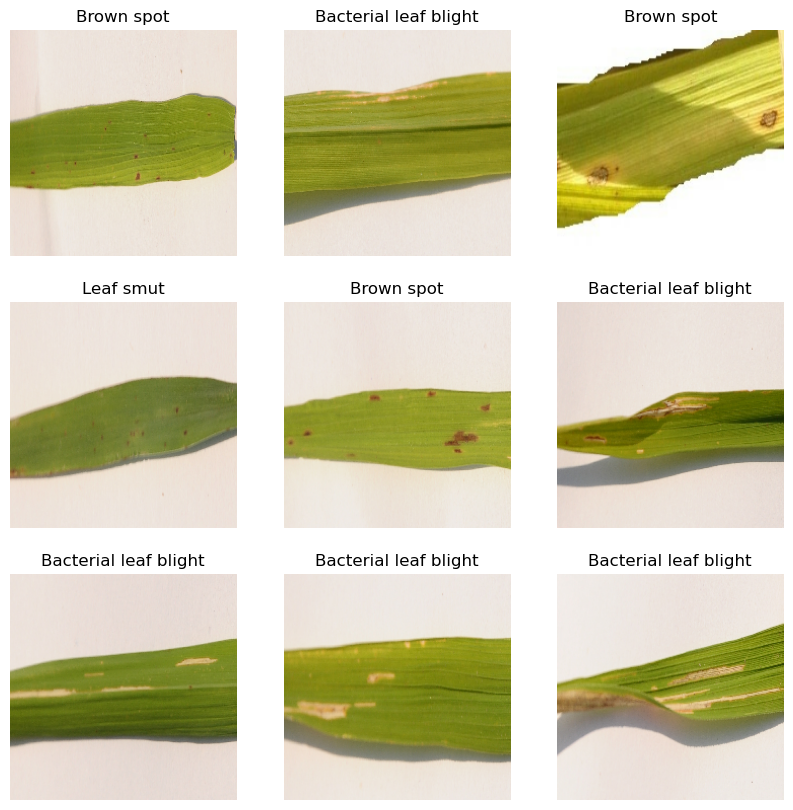

In [12]:
plt.figure(figsize=(10, 10))
for images, labels in train_val_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    img = images[i].numpy()
    if img.max() <= 1.0:
        img = (img * 255).astype("uint8")
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i].numpy()])
    plt.axis("off")

## Task-2: Build a Model to predict the three types of leaf diseases

In [13]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models

#### Preseting the values and Building a simple CNN Model to test for the database

In [14]:
#  Configure datasets for performance

AUTOTUNE = tf.data.AUTOTUNE

train_val_ds = train_val_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

# -------------------------------
# 1. Simple CNN Model
# -------------------------------

simple_cnn = models.Sequential([
  layers.Rescaling(1./255, input_shape=(224, 224, 3)),
  layers.Conv2D(32, (3,3), padding='same', activation='relu'),
  layers.MaxPooling2D(2,2),
  layers.Conv2D(64, (3,3), padding='same', activation='relu'),
  layers.MaxPooling2D(2,2),
  layers.Conv2D(128, (3,3), padding='same', activation='relu'),
  layers.MaxPooling2D(2,2),
  layers.Dropout(0.3),
  layers.Flatten(),
  layers.Dense(3,activation = 'softmax')
])

# Compile the model

simple_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print(simple_cnn.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)                │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 224, 224, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 112, 112, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 112, 112, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 56, 56, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 56, 56, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 28, 28, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 28, 28, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 100352)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 3)                   │         301,059 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 394,307 (1.50 MB)

 Trainable params: 394,307 (1.50 MB)

 Non-trainable params: 0 (0.00 B)

None


In [15]:
#training the model
epochs=20
history_simple = simple_cnn.fit(
  train_val_ds,
  validation_data=val_ds,
  epochs=epochs
)


Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.4286 - loss: 2.2115 - val_accuracy: 0.4688 - val_loss: 1.0457
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 958ms/step - accuracy: 0.3095 - loss: 1.2386 - val_accuracy: 0.4688 - val_loss: 1.0830
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 955ms/step - accuracy: 0.3571 - loss: 1.0722 - val_accuracy: 0.3750 - val_loss: 1.1906
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 945ms/step - accuracy: 0.4286 - loss: 1.0527 - val_accuracy: 0.3750 - val_loss: 1.0828
Epoch 5/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 984ms/step - accuracy: 0.5357 - loss: 0.9983 - val_accuracy: 0.5000 - val_loss: 1.0337
Epoch 6/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.5833 - loss: 0.9141 - val_accuracy: 0.4688 - val_loss: 0.9841
Epoch 7/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 943ms/step - accuracy: 0.5833 - loss: 0.8460 - val_accuracy: 0.6562 - val_loss: 0.8379
Epoch 8/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.6310 - loss: 0.7991 - val_accuracy: 0.4062 - val_loss: 1.2615
E

In [16]:
#  Evaluate the model

test_loss, test_acc = simple_cnn.evaluate(test_ds)
print("\n Test Accuracy:", round(test_acc * 100, 2), "%")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step - accuracy: 0.3333 - loss: 1.3028

 Test Accuracy: 33.33 %


#### Plotting graph for Simple CNN test, validation accuracy and loss

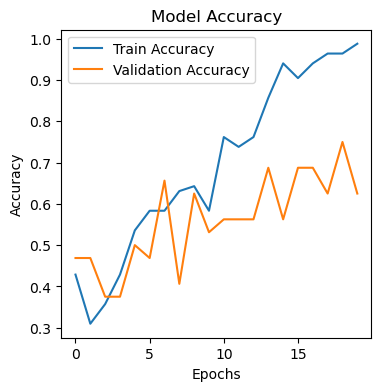

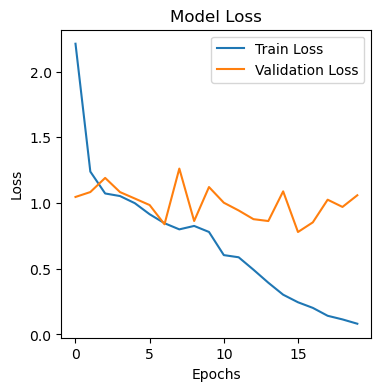

In [17]:
#plotting the graph for accuracy and loss

plt.figure(figsize=(4,4))
plt.plot(history_simple.history['accuracy'], label='Train Accuracy')
plt.plot(history_simple.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.figure(figsize=(4,4))
plt.plot(history_simple.history['loss'], label='Train Loss')
plt.plot(history_simple.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


#### Building a CNN model with light Augmentation

In [18]:
# -------------------------------
# 2. CNN with Light Augmentation
# -------------------------------
light_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1)
])

# Apply augmentation to dataset
train_ds_light = train_val_ds.map(lambda x, y: (light_augmentation(x, training=True), y), num_parallel_calls=AUTOTUNE)

light_cnn = models.Sequential([
    layers.Rescaling(1./255, input_shape=(224,224,3)),
    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D(2,2),
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(3, activation='softmax')
])

light_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
print(light_cnn.summary())

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)              │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 224, 224, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 112, 112, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 112, 112, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 56, 56, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 56, 56, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 28, 28, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 128)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 3)                   │             387 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 110,147 (430.26 KB)

 Trainable params: 110,147 (430.26 KB)

 Non-trainable params: 0 (0.00 B)

None


In [19]:
history_light = light_cnn.fit(
    train_ds_light,
    validation_data=val_ds,
    epochs=20
)

Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.4167 - loss: 1.0912 - val_accuracy: 0.1875 - val_loss: 1.1558
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 969ms/step - accuracy: 0.4048 - loss: 1.0897 - val_accuracy: 0.1875 - val_loss: 1.1639
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.4286 - loss: 1.0798 - val_accuracy: 0.3125 - val_loss: 1.1340
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 973ms/step - accuracy: 0.4405 - loss: 1.0719 - val_accuracy: 0.3125 - val_loss: 1.1444
Epoch 5/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 973ms/step - accuracy: 0.4524 - loss: 1.0783 - val_accuracy: 0.3125 - val_loss: 1.1406
Epoch 6/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 989ms/step - accuracy: 0.4286 - loss: 1.0635 - val_accuracy: 0.3438 - val_loss: 1.1298
Epoch 7/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 993ms/step - accuracy: 0.4405 - loss: 1.0568 - val_accuracy: 0.4062 - val_loss: 1.1138
Epoch 8/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 973ms/step - accuracy: 0.4762 - loss: 1.0469 - val_accuracy: 0.4062 - val_loss: 1.092

In [20]:
#  Evaluate the model

test_loss, test_acc = light_cnn.evaluate(test_ds)
print("\n Test Accuracy:", round(test_acc * 100, 2), "%")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 1.0000 - loss: 0.5022

 Test Accuracy: 100.0 %


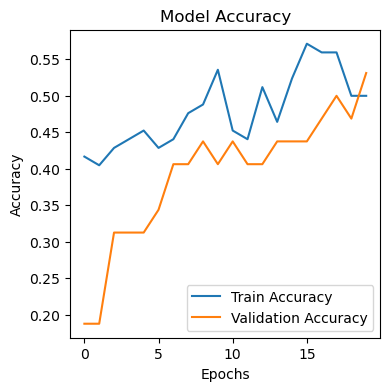

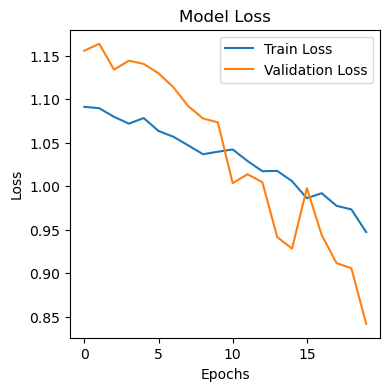

In [50]:
#plotting the graph for accuracy and loss

plt.figure(figsize=(4,4))
plt.plot(history_light.history['accuracy'], label='Train Accuracy')
plt.plot(history_light.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.figure(figsize=(4,4))
plt.plot(history_light.history['loss'], label='Train Loss')
plt.plot(history_light.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


#### Observations
- The model with light augmentation has performed well with the genereated parameters
- Instead of Flatten, the model is build with GlobalAveragePooling for two reasons
- Flatten needs a large dataset to generate the clear consice images but in small dataset case where our dataset has only 119 sample images, it decrease the model performance, as it builds around 2.19 million samples which are useless as they are derived from only 119 imagees.
- While GlobalAveragePooling works well as it doesn't generate exceesive load of images and works well with smaller dataset.
- We also trained the model using only train_batch augmentation instead of whole to remove any overfitting for the model.
- Here the obtained total parameters are relatively less compared to the Simple CNN model, as we are using the GlobalAveragePooling, which is why this model outperforms the 1st model i.e SimpleCNN.
- By observing the above graphs we can say the model is performing quite well as they are getting close to each other, which leads to the conclusion that the model is learning and generalizing.

#### Visualizing the light augumented images

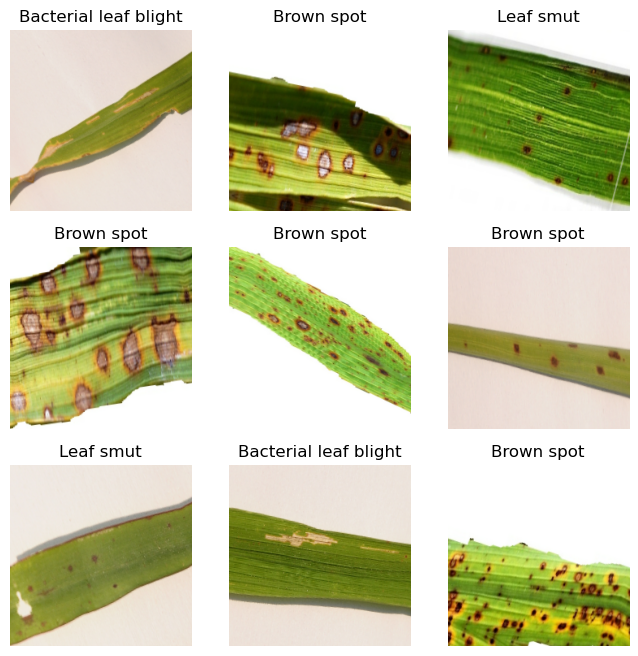

In [49]:
##Visualization for LIght augumented images
plt.figure(figsize=(8,8))
for images, labels in train_ds_light.take(1):
    for i in range(9):
        ax = plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i].numpy()])
        plt.axis("off")
plt.show()

#### Building the third model CNN with Heavy Augmentation

In [22]:
# -------------------------------
# 3. CNN with heavy Augmentation
# -------------------------------
heavy_augmentation = keras.Sequential([
    layers.Rescaling(1./255, input_shape=(224,224,3)), 
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.1),
    layers.RandomBrightness(0.2),
])

train_ds_heavy = train_val_ds.map(lambda x, y: (heavy_augmentation(x, training=True), y), num_parallel_calls=AUTOTUNE)

In [23]:

#  Build CNN Model with augmentation
heavy_cnn = models.Sequential([
    heavy_augmentation,
    layers.Rescaling(1./255, input_shape=(224, 224, 3)),
    
    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D(2,2),
    
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D(2,2),
    
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D(2,2),
    
    layers.GlobalAveragePooling2D(),     
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(3, activation='softmax')
])
# Compile the model

heavy_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print(heavy_cnn.summary())

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ sequential_3 (Sequential)            │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ rescaling_3 (Rescaling)              │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 224, 224, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 112, 112, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 112, 112, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 56, 56, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 56, 56, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_8 (MaxPooling2D)       │ (None, 28, 28, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_1           │ (None, 128)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 3)                   │             387 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 110,147 (430.26 KB)

 Trainable params: 110,147 (430.26 KB)

 Non-trainable params: 0 (0.00 B)

None


In [24]:
history_heavy = heavy_cnn.fit(
    train_ds_heavy,
    validation_data=val_ds,
    epochs=20
)

Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.3571 - loss: 1.0985 - val_accuracy: 0.1875 - val_loss: 1.1020
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.3810 - loss: 1.0949 - val_accuracy: 0.1875 - val_loss: 1.1049
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.3929 - loss: 1.0888 - val_accuracy: 0.1875 - val_loss: 1.1100
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.4048 - loss: 1.0943 - val_accuracy: 0.1875 - val_loss: 1.1156
Epoch 5/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.4048 - loss: 1.0974 - val_accuracy: 0.1875 - val_loss: 1.1183
Epoch 6/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.4048 - loss: 1.0924 - val_accuracy: 0.1875 - val_loss: 1.1227
Epoch 7/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.4048 - loss: 1.0849 - val_accuracy: 0.1875 - val_loss: 1.1257
Epoch 8/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.4048 - loss: 1.0941 - val_accuracy: 0.1875 - val_loss: 1.1283
Epoch 9/20
3/3 ━

In [25]:
#  Evaluate the model

test_loss, test_acc = heavy_cnn.evaluate(test_ds)
print("\n Test Accuracy:", round(test_acc * 100, 2), "%")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.3333 - loss: 1.1151

 Test Accuracy: 33.33 %


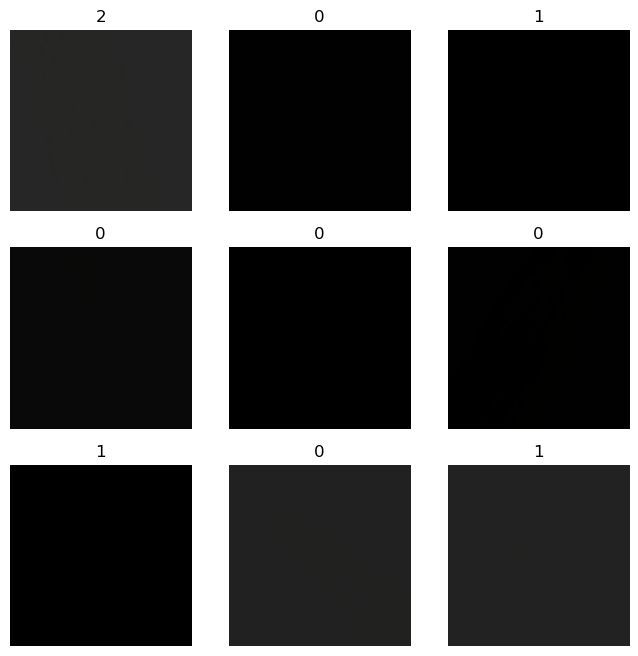

In [26]:
# Visualize heavy augmented images
plt.figure(figsize=(8,8))
for images, labels in train_ds_heavy.take(1):
    for i in range(9):
        ax = plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(int(labels[i].numpy()))
        plt.axis("off")
plt.show()

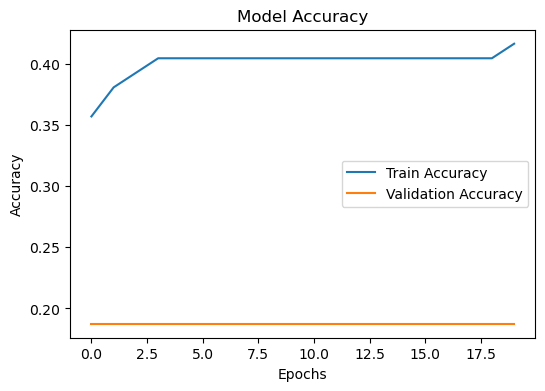

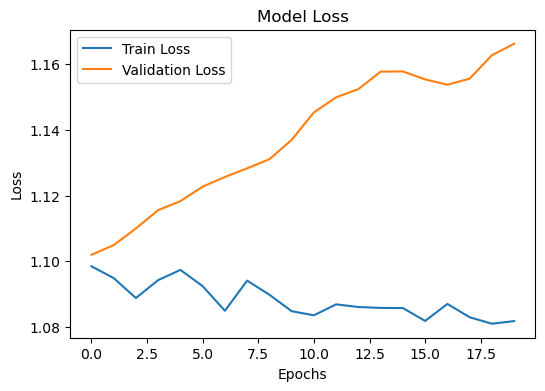

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(history_heavy.history['accuracy'], label='Train Accuracy')
plt.plot(history_heavy.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.figure(figsize=(6,4))
plt.plot(history_heavy.history['loss'], label='Train Loss')
plt.plot(history_heavy.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


#### Observations:
- As we can see above, the images generated with heavy augmentation are just plain black image samples, which doesn't help in learning the real signal.
- That is the reason why model doesn't performed well.
- Albeit it has created the same number of parameters to the llght augmentated model, the model has not created useful samples for the model to learn.
- smaller datasets might confuse the cnn with heavy augmentation, so they are not learning properly
- From the above curves we can clearly see that the model is not learning anything.
- Training accuracy is very high while the validation accuracy is too low, which are clear signs of overfitting
- Similar case in Loss curves, training loss is decreasing and validation loss is increasing heights resulting in overfiitng.

### CNN model with Transfer Learning using ResNet50

In [28]:
# Transfer Learning: Rice Leaf Disease Classification
# Using ResNet50 as Feature Extractor

from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models
from tensorflow.keras.models import Model

In [29]:
# Preprocess for ResNet50

preprocess_input = tf.keras.applications.resnet50.preprocess_input

AUTOTUNE = tf.data.AUTOTUNE
train_ds_tf = train_val_ds.map(lambda x, y: (preprocess_input(x), y), num_parallel_calls=AUTOTUNE)
val_ds_tf = val_ds.map(lambda x, y: (preprocess_input(x), y), num_parallel_calls=AUTOTUNE)
test_ds_tf = test_ds.map(lambda x, y: (preprocess_input(x), y), num_parallel_calls=AUTOTUNE)

# ----------------------------------
# Load pre-trained ResNet50 base model
# ----------------------------------
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))
base_model.trainable = False   # Freeze layers

# ----------------------------------
# Custom classifier head
# ----------------------------------
transfer_model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(3, activation='softmax')  # 3 classes as per your encoding
])

# Compile the model

transfer_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [30]:
print(transfer_model.summary())

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)                │ (None, 7, 7, 2048)          │      23,587,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_2           │ (None, 2048)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 128)                 │         262,272 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 3)                   │             387 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 23,850,371 (90.98 MB)

 Trainable params: 262,659 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

None


In [31]:
# ----------------------------------
# Train the model
# ----------------------------------
history_transfer = transfer_model.fit(
    train_ds_tf,
    validation_data=val_ds_tf,
    epochs=10
)

# ----------------------------------
# Fine-tune: Unfreeze last 10 layers for refined learning
# ----------------------------------
base_model.trainable = True
for layer in base_model.layers[:-10]:
    layer.trainable = False

transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
history_finetune = transfer_model.fit(
    train_ds_tf,
    validation_data=val_ds_tf,
    epochs=5
)

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 19s 4s/step - accuracy: 0.4405 - loss: 1.8243 - val_accuracy: 0.4688 - val_loss: 1.4084
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 18s 3s/step - accuracy: 0.7143 - loss: 0.7670 - val_accuracy: 0.5625 - val_loss: 0.9685
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 10s 3s/step - accuracy: 0.7857 - loss: 0.4718 - val_accuracy: 0.8125 - val_loss: 0.5609
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 10s 3s/step - accuracy: 0.9286 - loss: 0.2107 - val_accuracy: 0.8750 - val_loss: 0.5099
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 10s 3s/step - accuracy: 0.9405 - loss: 0.1867 - val_accuracy: 0.8750 - val_loss: 0.5507
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 10s 3s/step - accuracy: 0.9524 - loss: 0.1424 - val_accuracy: 0.8750 - val_loss: 0.4507
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 3s/step - accuracy: 0.9881 - loss: 0.0761 - val_accuracy: 0.8750 - val_loss: 0.5118
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 11s 3s/step - accuracy: 0.9524 - loss: 0.0890 - val_accuracy: 0.8750 - val_loss: 0.4604
Epoch 9/1

In [32]:
# Evaluate on test set

test_loss, test_acc = transfer_model.evaluate(test_ds)
print("\nTest Accuracy after Transfer Learning and Fine-tuning:", round(test_acc * 100, 2), "%")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 303ms/step - accuracy: 1.0000 - loss: 0.3884

Test Accuracy after Transfer Learning and Fine-tuning: 100.0 %


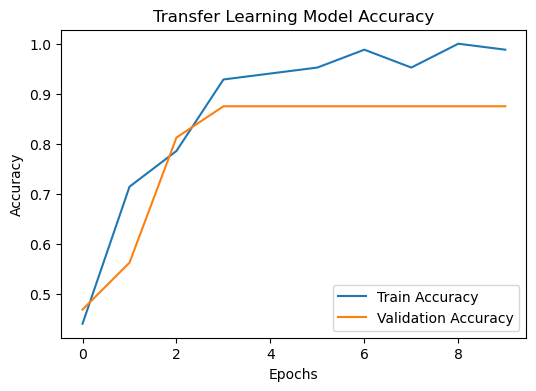

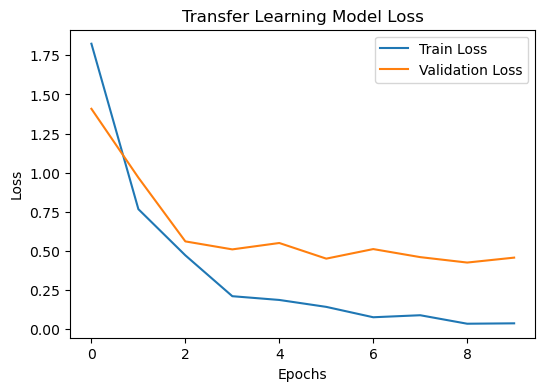

In [33]:
# Plot training curves

plt.figure(figsize=(6,4))
plt.plot(history_transfer.history['accuracy'], label='Train Accuracy')
plt.plot(history_transfer.history['val_accuracy'], label='Validation Accuracy')
plt.title('Transfer Learning Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.figure(figsize=(6,4))
plt.plot(history_transfer.history['loss'], label='Train Loss')
plt.plot(history_transfer.history['val_loss'], label='Validation Loss')
plt.title('Transfer Learning Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

#### Observations:
- We have used ResNet50, as it has pre-trained weights and sample images from different type of image classes, which helps in our case as the data provided is very small to amplify the data properly
- Using TransferLearning along with Resnet50 Finetuning we have generated over 23.8 Million training parameters where total trianalbe parameters are 260k parameters and non-trainable are 23.5 Million non-trainable parameters. It is expected as there might be only few leaf images where it can actually use in the model data, with similar leaf patterns.
- Here we have freeze the first 50 layers of ResNet50, so that the new classifiers were trainable, which allows the model to use pre-trained imagenet features without modifying them
- In Fine tuning all the layers except the last 10 layers are frozen, so only last 10 layers of convolutional layers of ResNet50 are trainable, which leads to train the dataset without overfitting.
- The model has given a 100.00% accuracy, which can lead to the statement that the model can predict the every type of sample image perfectly from the remianing batch value of images.
- From the above the plots we can conclude that the model is actually learning and genearlizing, which are required for a well trained model.
- In case of light augmentation and transfer learning model, where both have best trained models, the amount of parameters are diffferent, hence we can surely say that transfer learning performs rather well when compared to light augumentation.

## Task-3: Visualizing the Results of the Models

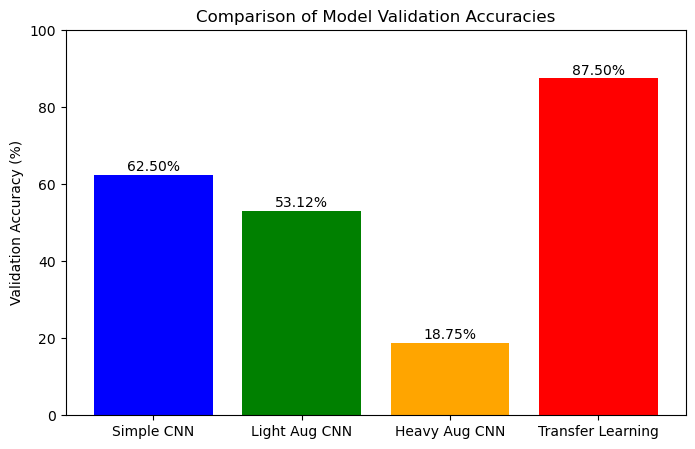

In [41]:
# Store the final validation accuracy for each model
model_accuracies = {
    "Simple CNN": history_simple.history['val_accuracy'][-1],
    "Light Aug CNN": history_light.history['val_accuracy'][-1],
    "Heavy Aug CNN": history_heavy.history['val_accuracy'][-1],
    "Transfer Learning": history_transfer.history['val_accuracy'][-1]
}

# Plot as a bar chart
plt.figure(figsize=(8, 5))
plt.bar(model_accuracies.keys(), [v * 100 for v in model_accuracies.values()], color=['blue', 'green', 'orange', 'red'])
plt.ylabel('Validation Accuracy (%)')
plt.title('Comparison of Model Validation Accuracies')
plt.ylim(0, 100)

# Add value labels on top of each bar
for i, v in enumerate(model_accuracies.values()):
    plt.text(i, v*100 + 1, f"{v*100:.2f}%", ha='center', fontsize=10)

plt.show()

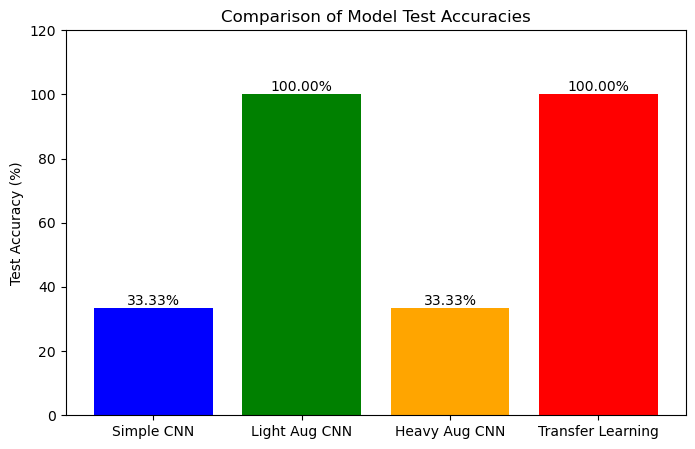

In [48]:
test_acc_simple = simple_cnn.evaluate(test_ds, verbose=0)[1]  # accuracy is index 1
test_acc_light_aug = light_cnn.evaluate(test_ds, verbose=0)[1]
test_acc_heavy_aug = heavy_cnn.evaluate(test_ds, verbose=0)[1]
test_acc_transfer = transfer_model.evaluate(test_ds, verbose=0)[1]

test_accuracies = {
    "Simple CNN": test_acc_simple,
    "Light Aug CNN": test_acc_light_aug,
    "Heavy Aug CNN": test_acc_heavy_aug,
    "Transfer Learning": test_acc_transfer
}

plt.figure(figsize=(8,5))
plt.bar(test_accuracies.keys(), [v*100 for v in test_accuracies.values()],
        color=['blue', 'green', 'orange', 'red'])
plt.ylabel("Test Accuracy (%)")
plt.title("Comparison of Model Test Accuracies")
plt.ylim(0, 120)

# Add value labels on top of bars
for i, v in enumerate(test_accuracies.values()):
    plt.text(i, v*100 + 1, f"{v*100:.2f}%", ha='center', fontsize=10)

plt.show()

### Plotting the accuracies in a single plot to show the differences of the model

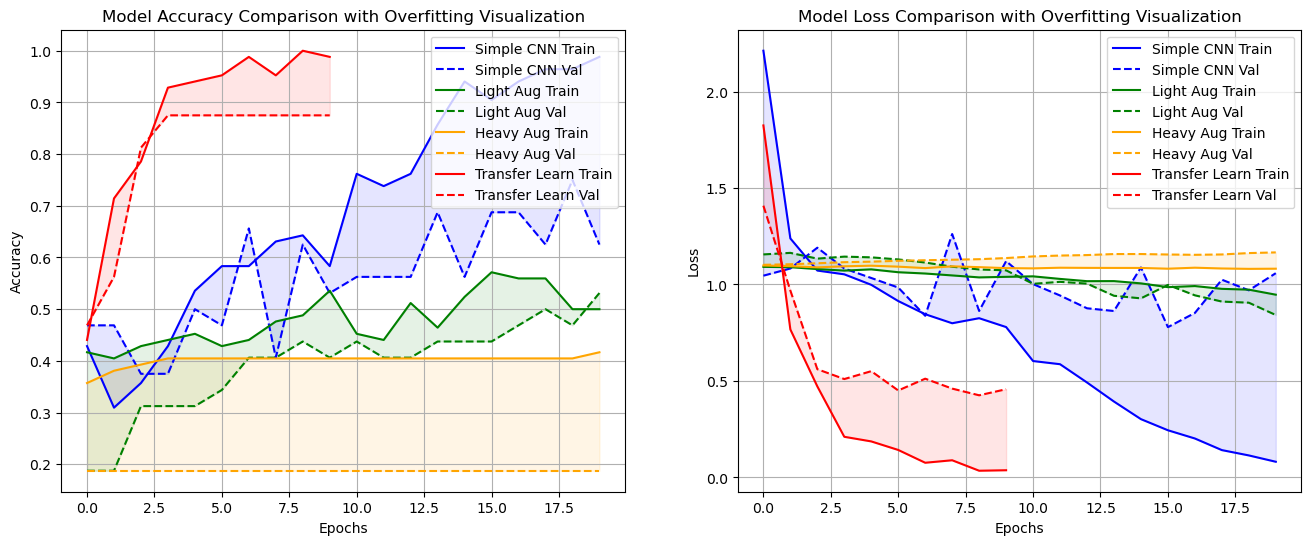

In [52]:
plt.figure(figsize=(16, 6))

# ------------------ Accuracy ------------------
plt.subplot(1, 2, 1)

# Simple CNN
plt.plot(history_simple.history['accuracy'], label='Simple CNN Train', color='blue')
plt.plot(history_simple.history['val_accuracy'], label='Simple CNN Val', color='blue', linestyle='--')
plt.fill_between(range(len(history_simple.history['accuracy'])),
                 history_simple.history['accuracy'],
                 history_simple.history['val_accuracy'],
                 color='blue', alpha=0.1)

# Light Augmentation
plt.plot(history_light.history['accuracy'], label='Light Aug Train', color='green')
plt.plot(history_light.history['val_accuracy'], label='Light Aug Val', color='green', linestyle='--')
plt.fill_between(range(len(history_light.history['accuracy'])),
                 history_light.history['accuracy'],
                 history_light.history['val_accuracy'],
                 color='green', alpha=0.1)

# Heavy Augmentation
plt.plot(history_heavy.history['accuracy'], label='Heavy Aug Train', color='orange')
plt.plot(history_heavy.history['val_accuracy'], label='Heavy Aug Val', color='orange', linestyle='--')
plt.fill_between(range(len(history_heavy.history['accuracy'])),
                 history_heavy.history['accuracy'],
                 history_heavy.history['val_accuracy'],
                 color='orange', alpha=0.1)

# Transfer Learning
plt.plot(history_transfer.history['accuracy'], label='Transfer Learn Train', color='red')
plt.plot(history_transfer.history['val_accuracy'], label='Transfer Learn Val', color='red', linestyle='--')
plt.fill_between(range(len(history_transfer.history['accuracy'])),
                 history_transfer.history['accuracy'],
                 history_transfer.history['val_accuracy'],
                 color='red', alpha=0.1)

plt.title('Model Accuracy Comparison with Overfitting Visualization')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# ------------------ Loss ------------------
plt.subplot(1, 2, 2)

# Simple CNN
plt.plot(history_simple.history['loss'], label='Simple CNN Train', color='blue')
plt.plot(history_simple.history['val_loss'], label='Simple CNN Val', color='blue', linestyle='--')
plt.fill_between(range(len(history_simple.history['loss'])),
                 history_simple.history['loss'],
                 history_simple.history['val_loss'],
                 color='blue', alpha=0.1)

# Light Augmentation
plt.plot(history_light.history['loss'], label='Light Aug Train', color='green')
plt.plot(history_light.history['val_loss'], label='Light Aug Val', color='green', linestyle='--')
plt.fill_between(range(len(history_light.history['loss'])),
                 history_light.history['loss'],
                 history_light.history['val_loss'],
                 color='green', alpha=0.1)

# Heavy Augmentation
plt.plot(history_heavy.history['loss'], label='Heavy Aug Train', color='orange')
plt.plot(history_heavy.history['val_loss'], label='Heavy Aug Val', color='orange', linestyle='--')
plt.fill_between(range(len(history_heavy.history['loss'])),
                 history_heavy.history['loss'],
                 history_heavy.history['val_loss'],
                 color='orange', alpha=0.1)

# Transfer Learning
plt.plot(history_transfer.history['loss'], label='Transfer Learn Train', color='red')
plt.plot(history_transfer.history['val_loss'], label='Transfer Learn Val', color='red', linestyle='--')
plt.fill_between(range(len(history_transfer.history['loss'])),
                 history_transfer.history['loss'],
                 history_transfer.history['val_loss'],
                 color='red', alpha=0.1)

plt.title('Model Loss Comparison with Overfitting Visualization')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

### Final Notes:
- From the above plots we can see that the transfer learn outperforms everymodel in both model accuracy and model loss comparison.
- For small datasets CNN using Transfer learning is found out to be best one to train for small datasets.